In [1]:
!python --version

Python 3.12.13


In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
df = pd.read_csv("Job_3_Resource_sentiment.csv")

In [4]:
df.head(5)

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [5]:
df.sample(10)

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
44642,11667,Verizon,Neutral,Boxes running on tablets fill up their library...
21028,12799,WorldOfCraft,Positive,@Warcraft leveling just looks really interesti...
52235,10574,RedDeadRedemption(RDR),Positive,"Mass effect, Red dead redemption, Batman Arkha..."
70965,10956,TomClancysGhostRecon,Negative,1 RhandlerR RhandlerR RhandlerR RhandlerR i ne...
11598,13193,Xbox(Xseries),Negative,x box will not catch me until they change this...
35700,8130,Microsoft,Neutral,Windows Update not only automatically updates ...
71370,11025,TomClancysGhostRecon,Neutral,"Shocked, you could climb up there."
4868,37,Amazon,Neutral,NaN
39295,5545,Hearthstone,Neutral,@ WillingBlam was as brilliant as Reno Jackson...
24937,4682,Google,Positive,"In this case, I'm happy to have joined forces ..."


In [6]:
df.shape

(74681, 4)

In [7]:
df.columns

Index(['2401', 'Borderlands', 'Positive',
       'im getting on borderlands and i will murder you all ,'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   2401                                                   74681 non-null  int64 
 1   Borderlands                                            74681 non-null  object
 2   Positive                                               74681 non-null  object
 3   im getting on borderlands and i will murder you all ,  73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [9]:
df.describe()

,2401
count,74681.000000
mean,6432.640149
std,3740.423819
min,1.000000
25%,3195.000000
50%,6422.000000
75%,9601.000000
max,13200.000000


In [10]:
df.rename(columns={'Positive': 'sentiment'}, inplace=True)

In [11]:
df

,2401,Borderlands,sentiment,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...
...,...,...,...,...
74676,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74677,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74678,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74679,9200,Nvidia,Positive,Just realized between the windows partition of...


In [12]:
df.rename(columns={'im getting on borderlands and i will murder you all ,': 'text'}, inplace=True)

In [13]:
df.sample(5)

,2401,Borderlands,sentiment,text
52651,10645,RedDeadRedemption(RDR),Neutral,The human-like mutant RDR2 is the most secret ...
48795,5976,HomeDepot,Neutral,from @DaltonRoss @robcesternino From Rewatchin...
31609,7427,LeagueOfLegends,Irrelevant,@ vgeney is a lucky man.
61597,4958,GrandTheftAuto(GTA),Positive,Just returned to GTA online and my god really ...
11512,13178,Xbox(Xseries),Positive,That is superb from Xbox. Fun as moving about ...


In [14]:
df = df[['text', 'sentiment']]

In [15]:
df

,text,sentiment
0,I am coming to the borders and I will kill you...,Positive
1,im getting on borderlands and i will kill you ...,Positive
2,im coming on borderlands and i will murder you...,Positive
3,im getting on borderlands 2 and i will murder ...,Positive
4,im getting into borderlands and i can murder y...,Positive
...,...,...
74676,Just realized that the Windows partition of my...,Positive
74677,Just realized that my Mac window partition is ...,Positive
74678,Just realized the windows partition of my Mac ...,Positive
74679,Just realized between the windows partition of...,Positive


In [16]:
df.shape

(74681, 2)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       73995 non-null  object
 1   sentiment  74681 non-null  object
dtypes: object(2)
memory usage: 1.1+ MB


In [18]:
df.describe()

,text,sentiment
count,73995,74681
unique,69490,4
top,,Negative
freq,172,22542


In [19]:
df.columns

Index(['text', 'sentiment'], dtype='object')

In [20]:
df.isnull().sum()

,0
text,686
sentiment,0


In [21]:
print(df['sentiment'].value_counts())

sentiment
Negative      22542
Positive      20831
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


In [22]:
df.duplicated().sum()

np.int64(4909)

In [23]:
df.drop_duplicates(inplace=True)

/tmp/ipykernel_1870/3006716147.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(inplace=True)


In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
df.dropna(inplace=True)

/tmp/ipykernel_1870/1379821321.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


In [26]:
df.isnull().sum()

,0
text,0
sentiment,0


In [27]:
df.shape

(69768, 2)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 69768 entries, 0 to 74680
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       69768 non-null  object
 1   sentiment  69768 non-null  object
dtypes: object(2)
memory usage: 1.6+ MB


In [29]:
df.describe()

,text,sentiment
count,69768,69768
unique,69490,4
top,by,Negative
freq,4,21237


In [30]:
df.sample(10)

,text,sentiment
64344,I cry!.,Irrelevant
59115,... Creepy geek not only an intellectual prope...,Irrelevant
7061,I miss spamming stay on the payload in overwatch,Negative
32361,AND RIOT YOU COWARDS TO JUST TO MAKE AN EVERYO...,Negative
23939,I’m tired of excuses for older people when it ...,Irrelevant
15117,Hey @DOTA2 or the way you updated the ranks la...,Negative
14153,looked at r/dota2 again. mistake. this sub is ...,Irrelevant
2803,22 murderous series in the first game of the C...,Neutral
29011,Apex Legends GOLD III RANKED MATCHES - From Tr...,Neutral
59010,"This fat, juicy son of a nutcase BITCH! My ans...",Irrelevant


In [31]:
df['text'] = df['text'].astype(str)

/tmp/ipykernel_1870/1180961456.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['text'] = df['text'].astype(str)


In [32]:
df['text']

,text
0,I am coming to the borders and I will kill you...
1,im getting on borderlands and i will kill you ...
2,im coming on borderlands and i will murder you...
3,im getting on borderlands 2 and i will murder ...
4,im getting into borderlands and i can murder y...
...,...
74676,Just realized that the Windows partition of my...
74677,Just realized that my Mac window partition is ...
74678,Just realized the windows partition of my Mac ...
74679,Just realized between the windows partition of...


In [33]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text.strip()

df['text'] = df['text'].apply(clean_text)

/tmp/ipykernel_1870/1069262265.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['text'] = df['text'].apply(clean_text)


In [34]:
df['text']

,text
0,i am coming to the borders and i will kill you...
1,im getting on borderlands and i will kill you all
2,im coming on borderlands and i will murder you...
3,im getting on borderlands and i will murder y...
4,im getting into borderlands and i can murder y...
...,...
74676,just realized that the windows partition of my...
74677,just realized that my mac window partition is ...
74678,just realized the windows partition of my mac ...
74679,just realized between the windows partition of...


In [35]:
encoder = LabelEncoder()
df['sentiment_encoded'] = encoder.fit_transform(df['sentiment'])

print("Label mapping:")
for i, c in enumerate(encoder.classes_):
    print(i, "->", c)

Label mapping:
0 -> Irrelevant
1 -> Negative
2 -> Neutral
3 -> Positive


/tmp/ipykernel_1870/3100372417.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sentiment_encoded'] = encoder.fit_transform(df['sentiment'])


In [36]:
encoder

LabelEncoder()

In [37]:
encoder.classes_

array(['Irrelevant', 'Negative', 'Neutral', 'Positive'], dtype=object)

In [38]:
df

,text,sentiment,sentiment_encoded
0,i am coming to the borders and i will kill you...,Positive,3
1,im getting on borderlands and i will kill you all,Positive,3
2,im coming on borderlands and i will murder you...,Positive,3
3,im getting on borderlands and i will murder y...,Positive,3
4,im getting into borderlands and i can murder y...,Positive,3
...,...,...,...
74676,just realized that the windows partition of my...,Positive,3
74677,just realized that my mac window partition is ...,Positive,3
74678,just realized the windows partition of my mac ...,Positive,3
74679,just realized between the windows partition of...,Positive,3


In [39]:
max_words = 20000
max_length = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="")
tokenizer.fit_on_texts(df['text'])

X = pad_sequences(
    tokenizer.texts_to_sequences(df['text']),
    maxlen=max_length,
    padding='post'
)

y = df['sentiment_encoded'].values

In [40]:
tokenizer

In [41]:
X

array([[   3,   98,  370, ...,    0,    0,    0],
       [  31,  155,   14, ...,    0,    0,    0],
       [  31,  370,   14, ...,    0,    0,    0],
       ...,
       [  21, 1830,    2, ...,    0,    0,    0],
       [  21, 1830,  683, ...,    0,    0,    0],
       [  21,   32,    2, ...,    0,    0,    0]], dtype=int32)

In [42]:
X.shape

(69768, 100)

In [43]:
y

array([3, 3, 3, ..., 3, 3, 3])

In [44]:
y.shape

(69768,)

In [45]:
df

,text,sentiment,sentiment_encoded
0,i am coming to the borders and i will kill you...,Positive,3
1,im getting on borderlands and i will kill you all,Positive,3
2,im coming on borderlands and i will murder you...,Positive,3
3,im getting on borderlands and i will murder y...,Positive,3
4,im getting into borderlands and i can murder y...,Positive,3
...,...,...,...
74676,just realized that the windows partition of my...,Positive,3
74677,just realized that my mac window partition is ...,Positive,3
74678,just realized the windows partition of my mac ...,Positive,3
74679,just realized between the windows partition of...,Positive,3


In [46]:
X.dtype

dtype('int32')

In [47]:
y.dtype

dtype('int64')

In [48]:
X.ndim

2

In [49]:
y.ndim

1

In [50]:
X.nbytes

27907200

In [51]:
y.nbytes

558144

In [52]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("\nTrain:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (48837, 100)
Validation: (10465, 100)
Test: (10466, 100)


In [53]:
X_train

array([[    1,   211,    27, ...,     0,     0,     0],
       [    3,   799,   578, ...,     0,     0,     0],
       [  436,  1394,  5377, ...,     0,     0,     0],
       ...,
       [  151,    36,   198, ...,     0,     0,     0],
       [  394,   548,   370, ...,     0,     0,     0],
       [  136,   196, 13157, ...,     0,     0,     0]], dtype=int32)

In [54]:
X_temp

array([[1463,  210,   53, ...,    0,    0,    0],
       [ 537,   40,  129, ...,    0,    0,    0],
       [  15,  126,  651, ...,    0,    0,    0],
       ...,
       [   7,   83,   86, ...,    0,    0,    0],
       [   3,   98,    3, ...,    0,    0,    0],
       [ 589,    3,   21, ...,    0,    0,    0]], dtype=int32)

In [55]:
X_test

array([[  35,   54,  126, ...,    0,    0,    0],
       [  11,    8,   29, ...,    0,    0,    0],
       [1994,  918, 7480, ...,    0,    0,    0],
       ...,
       [ 151,   60,   58, ...,    0,    0,    0],
       [7992,   72, 1293, ...,    0,    0,    0],
       [ 857, 2648,  211, ...,    0,    0,    0]], dtype=int32)

In [56]:
X_val

array([[   2, 1891,  228, ...,    0,    0,    0],
       [   5,    3,   32, ...,    0,    0,    0],
       [  90, 7372,  744, ...,    0,    0,    0],
       ...,
       [  19,   15, 2471, ...,    0,    0,    0],
       [   3,  226, 2177, ...,    0,    0,    0],
       [   3,  192, 1119, ...,    0,    0,    0]], dtype=int32)

In [57]:
y_temp

array([3, 1, 3, ..., 1, 3, 0])

In [58]:
y_test

array([3, 3, 2, ..., 1, 2, 1])

In [59]:
y_train

array([1, 0, 0, ..., 3, 1, 3])

In [60]:
y_val

array([3, 2, 1, ..., 2, 3, 0])

In [61]:
y_train.shape

(48837,)

In [62]:
print(np.bincount(y_train))

[ 8598 14866 11977 13396]


In [63]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))
print("\nClass Weights:", class_weights_dict)



Class Weights: {0: np.float64(1.4200104675505931), 1: np.float64(0.821286829005785), 2: np.float64(1.0193913333889957), 3: np.float64(0.9114101224246044)}


In [64]:
class_weights

array([1.42001047, 0.82128683, 1.01939133, 0.91141012])

In [65]:
print(np.bincount(y_train))

[ 8598 14866 11977 13396]


In [66]:
model = Sequential([
    Input(shape=(max_length,)),
    Embedding(max_words, 128),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,659,332 (10.14 MB)

 Trainable params: 2,659,332 (10.14 MB)

 Non-trainable params: 0 (0.00 B)

In [67]:
model

<Sequential name=sequential, built=True>

In [68]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [69]:
model

<Sequential name=sequential, built=True>

In [70]:
early = EarlyStopping(patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early],
    class_weight=class_weights_dict
)

Epoch 1/20
1527/1527 ━━━━━━━━━━━━━━━━━━━━ 260s 168ms/step - accuracy: 0.6335 - loss: 0.9126 - val_accuracy: 0.7665 - val_loss: 0.6177
Epoch 2/20
1527/1527 ━━━━━━━━━━━━━━━━━━━━ 240s 157ms/step - accuracy: 0.8366 - loss: 0.4571 - val_accuracy: 0.8269 - val_loss: 0.4684
Epoch 3/20
1527/1527 ━━━━━━━━━━━━━━━━━━━━ 236s 154ms/step - accuracy: 0.8936 - loss: 0.2976 - val_accuracy: 0.8512 - val_loss: 0.4187
Epoch 4/20
1527/1527 ━━━━━━━━━━━━━━━━━━━━ 237s 155ms/step - accuracy: 0.9194 - loss: 0.2231 - val_accuracy: 0.8608 - val_loss: 0.4226
Epoch 5/20
1527/1527 ━━━━━━━━━━━━━━━━━━━━ 236s 154ms/step - accuracy: 0.9354 - loss: 0.1786 - val_accuracy: 0.8742 - val_loss: 0.4226
Epoch 6/20
1527/1527 ━━━━━━━━━━━━━━━━━━━━ 268s 158ms/step - accuracy: 0.9457 - loss: 0.1521 - val_accuracy: 0.8740 - val_loss: 0.4255


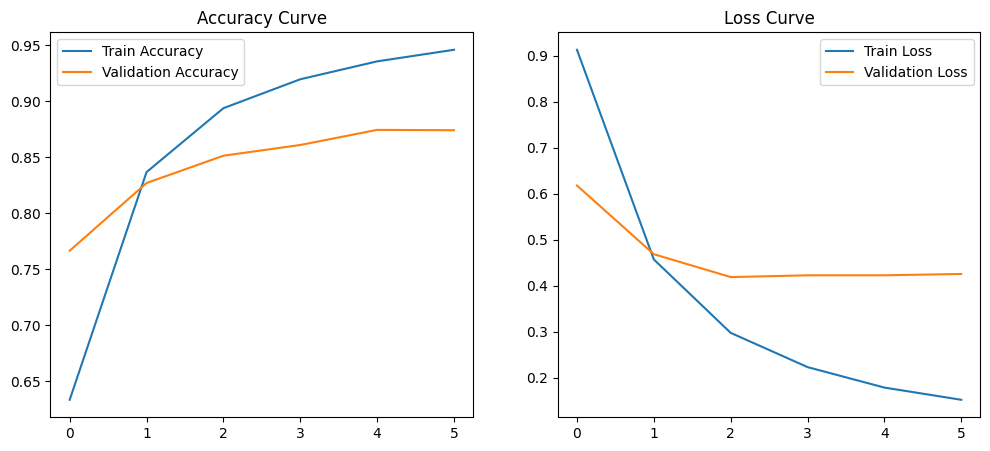

In [71]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

In [72]:
history.history['accuracy'][-1]

0.9457173943519592

In [73]:
history.history['val_accuracy'][-1]

0.8739607930183411

In [74]:
if history.history['accuracy'][-1] > history.history['val_accuracy'][-1]:
    print("⚠️ Possible Overfitting detected")
else:
    print("✅ Model is generalizing well")

⚠️ Possible Overfitting detected


In [75]:
print("Accuracy:", accuracy_score(y_test, np.argmax(model.predict(X_test), axis=1)))
print(classification_report(y_test, np.argmax(model.predict(X_test), axis=1)))

328/328 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step
Accuracy: 0.8546722721192432
328/328 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step
              precision    recall  f1-score   support

           0       0.82      0.85      0.83      1843
           1       0.87      0.88      0.87      3186
           2       0.86      0.83      0.85      2566
           3       0.86      0.85      0.85      2871

    accuracy                           0.85     10466
   macro avg       0.85      0.85      0.85     10466
weighted avg       0.85      0.85      0.85     10466



In [76]:
model.save("sentiment_analysis_model.keras")
print("✅ Model saved successfully")

✅ Model saved successfully


In [77]:
def predict_sentiment(text):
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=100, padding='post')
    probs = model.predict(pad)[0]
    return encoder.classes_[probs.argmax()], probs

texts = [
    "I love this game so much",
    "This game is terrible",
    "I have no opinion",
    "What is this even about?"
]

for t in texts:
    pred, prob = predict_sentiment(t)
    print(t, "->", pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
I love this game so much -> Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
This game is terrible -> Negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
I have no opinion -> Negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
What is this even about? -> Negative


In [79]:
with open("tokenizer.json", "w") as f:
    f.write(tokenizer.to_json())